# PROJETO 2 ANADI - E-REDES

In [1]:
# TODOS OS IMPORTS SÃO FEITOS AQUI PARA MANTER SIMPLICIDADE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import f_oneway, shapiro
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Carrega o dataset PTD
ptd_df = pd.read_excel("./data/PTD_level_dataset.xlsx")

## 4.2 - Pré-processamento de Dados

In [2]:
print("=" * 80)
print("DIMENSÃO DO DATASET")
print("=" * 80)
print(f"Número de registos (PTDs): {ptd_df.shape[0]}")
print(f"Número de variáveis: {ptd_df.shape[1]}")
print("\n" + "=" * 80)
print("TIPO DE DADOS E VALORES OMISSOS")
print("=" * 80)
print(ptd_df.dtypes)
print("\n" + "=" * 80)
print("VALORES OMISSOS")
print("=" * 80)
missing_count = ptd_df.isnull().sum()
missing_pct = (missing_count / len(ptd_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Variável': missing_count.index,
    'Omissos (n)': missing_count.values,
    'Omissos (%)': missing_pct.values
})
print(missing_df[missing_df['Omissos (n)'] > 0])
print("\n" + "=" * 80)
print("RESUMO ESTATÍSTICO")
print("=" * 80)
print(ptd_df.describe().round(4))

DIMENSÃO DO DATASET
Número de registos (PTDs): 72027
Número de variáveis: 32

TIPO DE DADOS E VALORES OMISSOS
Distrito                      object
Concelho                      object
CodDistritoConcelho            int64
Código de Instalação          object
Coordenadas Geográficas       object
Potência instalada [kVA]       int64
Tipo Construtivo              object
Cap_PTD_kVA                    int64
Pot_Contratada_kVA           float64
N_Clientes                     int64
Pot_Geracao_kW               float64
N_Clientes_Produtores          int64
P_IP_Total                   float64
P_IP_Inef                    float64
Rate_Ineficiencia            float64
LED_Ratio                    float64
N_Luminarias                   int64
N_Lampadas                     int64
N_PTDs_Concelho                int64
PVE_PTD                      float64
D_PTD                        float64
IP_per_PTD                   float64
IP_Inef_per_PTD              float64
Ganho_LED_PTD                float64
D_

### 4.1.2 - Análise de Distribuições

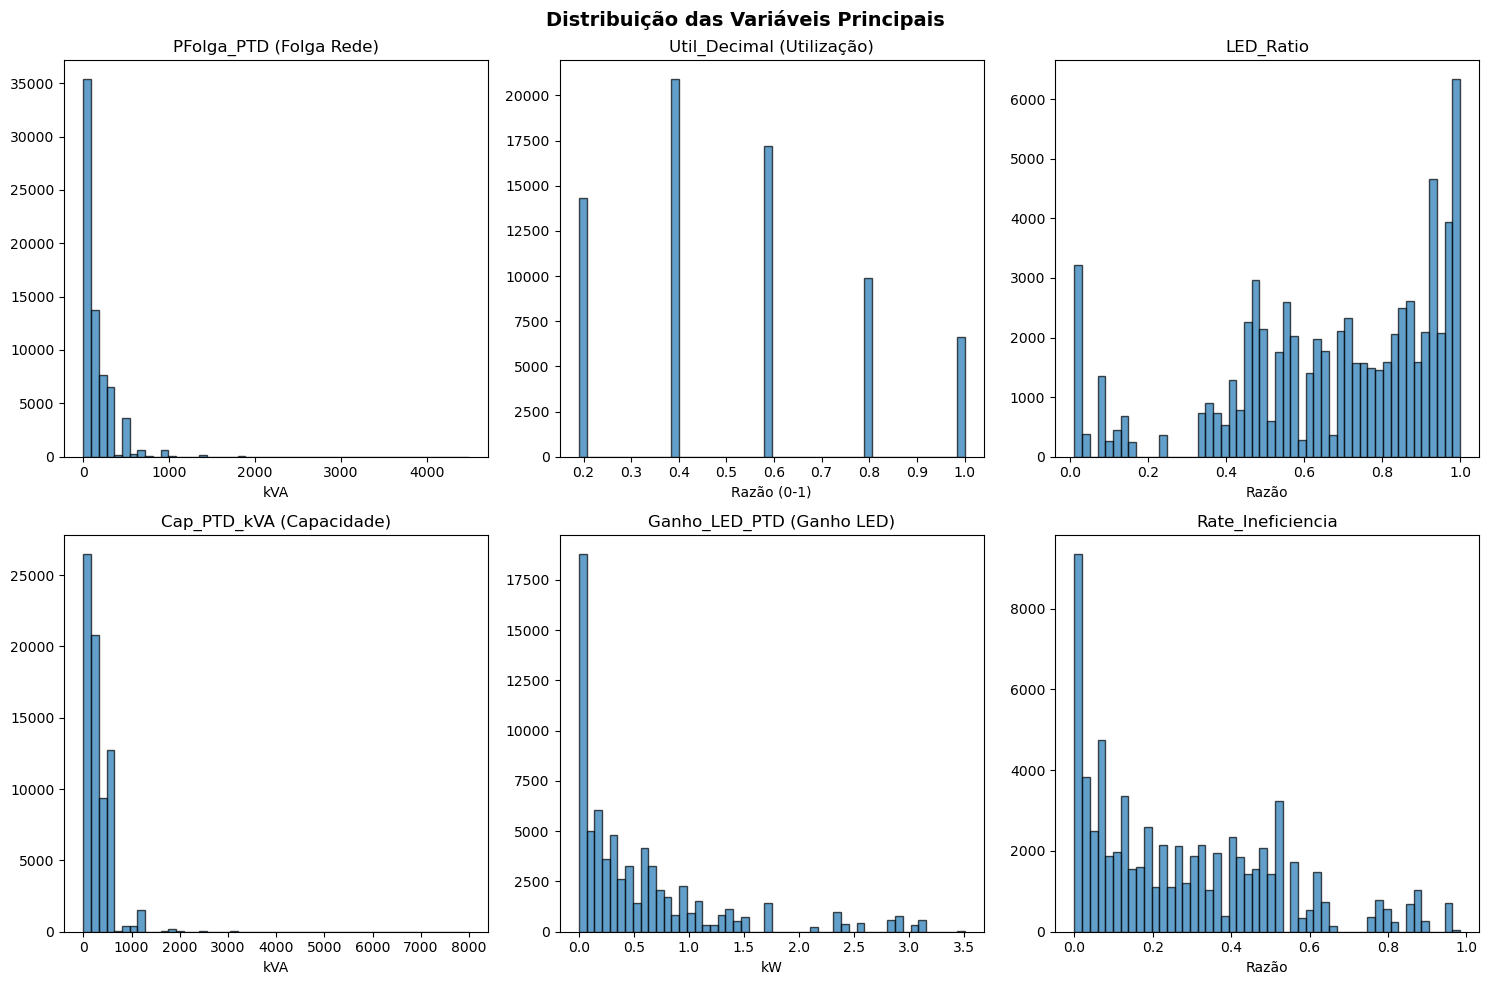

In [3]:
# Visualizar distribuições das variáveis numéricas principais
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Distribuição das Variáveis Principais", fontsize=14, fontweight='bold')

# Distribuição de PFolga_PTD
axes[0, 0].hist(ptd_df['PFolga_PTD'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('PFolga_PTD (Folga Rede)')
axes[0, 0].set_xlabel('kVA')

# Distribuição de Util_Decimal
axes[0, 1].hist(ptd_df['Util_Decimal'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Util_Decimal (Utilização)')
axes[0, 1].set_xlabel('Razão (0-1)')

# Distribuição de LED_Ratio
axes[0, 2].hist(ptd_df['LED_Ratio'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 2].set_title('LED_Ratio')
axes[0, 2].set_xlabel('Razão')

# Distribuição de Cap_PTD_kVA
axes[1, 0].hist(ptd_df['Cap_PTD_kVA'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Cap_PTD_kVA (Capacidade)')
axes[1, 0].set_xlabel('kVA')

# Distribuição de Ganho_LED_PTD
axes[1, 1].hist(ptd_df['Ganho_LED_PTD'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Ganho_LED_PTD (Ganho LED)')
axes[1, 1].set_xlabel('kW')

# Distribuição de Rate_Ineficiencia
axes[1, 2].hist(ptd_df['Rate_Ineficiencia'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1, 2].set_title('Rate_Ineficiencia')
axes[1, 2].set_xlabel('Razão')

plt.tight_layout()
plt.show()

### 4.1.3 - Análise de Correlação com a Variável Alvo (PFolga_PTD)

CORRELAÇÃO COM A VARIÁVEL ALVO (PFolga_PTD)
PFolga_PTD                   1.0000
D_PTD                        1.0000
D_PTD_LED                    1.0000
Cap_PTD_kVA                  0.8065
Potência instalada [kVA]     0.8065
Cap_per_Cliente              0.6327
P_IP_Total                   0.1477
N_PTDs_Concelho              0.1272
PContratada_per_Cliente      0.1086
Pot_Contratada_kVA           0.0879
P_IP_Inef                    0.0615
IP_per_PTD                   0.0560
N_Clientes                   0.0542
CodDistritoConcelho          0.0532
Clientes_Produtores_Ratio    0.0531
N_Lampadas                   0.0470
N_Luminarias                 0.0465
Geracao_per_Cliente          0.0338
Ganho_LED_PTD                0.0294
IP_Inef_per_PTD              0.0294
Rate_Ineficiencia           -0.0123
Pot_Geracao_kW              -0.0258
N_Clientes_Produtores       -0.0470
LED_Ratio                   -0.0550
Util_Decimal                -0.8321
PVE_PTD                         NaN
Name: PFolga_PTD, dt

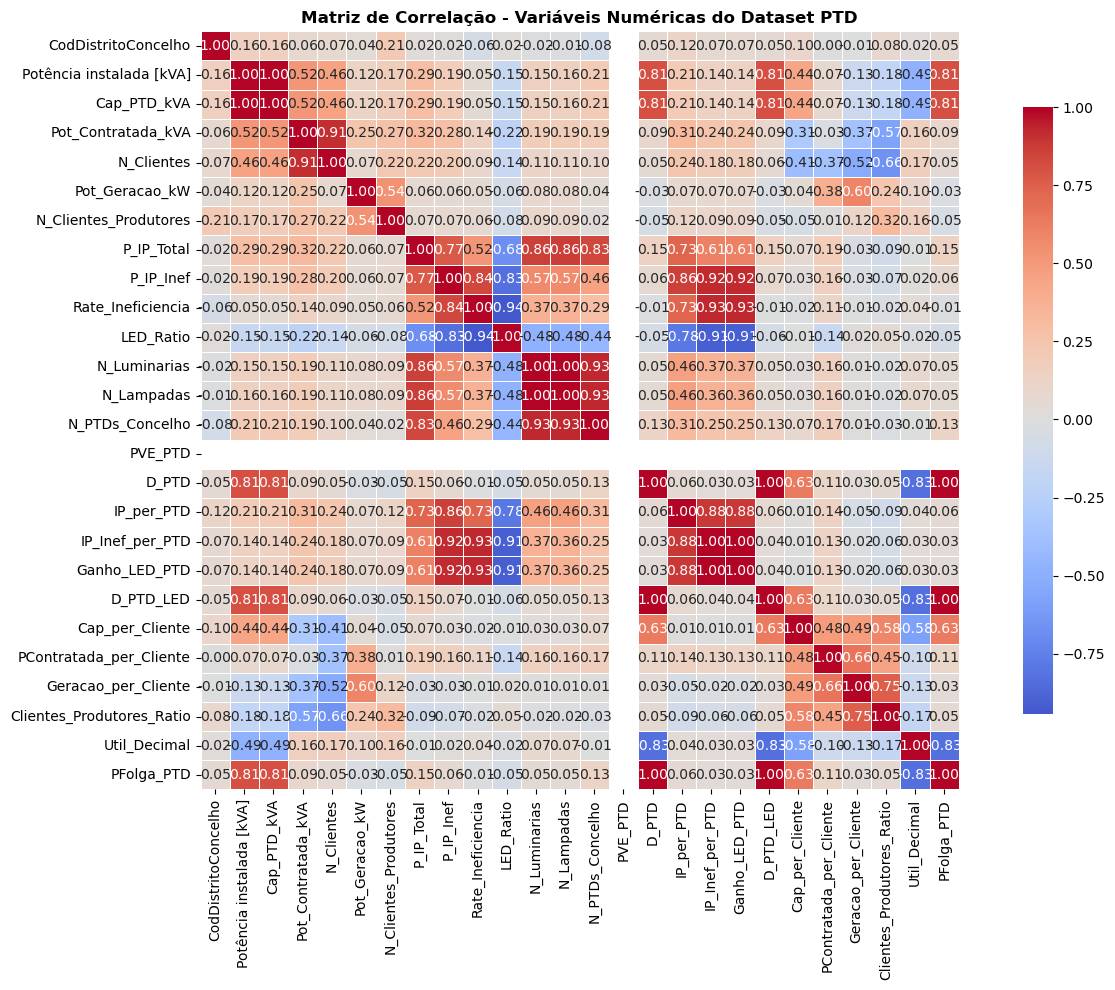

In [4]:
# Selecionar variáveis numéricas para correlação
numeric_cols = ptd_df.select_dtypes(include=[np.number]).columns
numeric_df = ptd_df[numeric_cols].dropna()

# Calcular correlação com PFolga_PTD
correlation_with_target = numeric_df.corr()['PFolga_PTD'].sort_values(ascending=False)

print("=" * 80)
print("CORRELAÇÃO COM A VARIÁVEL ALVO (PFolga_PTD)")
print("=" * 80)
print(correlation_with_target.round(4))

# Heatmap de correlação
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
plt.title("Matriz de Correlação - Variáveis Numéricas do Dataset PTD", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2.1 - Tratamento de Valores Omissos

In [5]:
# Criar uma cópia para trabalho
df_processed = ptd_df.copy()

print("=" * 80)
print("ESTRATÉGIA DE TRATAMENTO DE VALORES OMISSOS")
print("=" * 80)

# Colunas com omissões significativas a verificar
cols_with_missing = df_processed.columns[df_processed.isnull().any()].tolist()

# Para variáveis contínuas: imputar com mediana
for col in ['Pot_Contratada_kVA', 'Pot_Geracao_kW']:
    if col in cols_with_missing:
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)
        print(f"  → {col}: imputado com mediana ({median_val:.2f})")

# Para variáveis categóricas ou proporções
for col in ['Nível de Utilização [%]']:
    if col in cols_with_missing:
        mode_val = df_processed[col].mode()[0] if not df_processed[col].mode().empty else 0.5
        df_processed[col].fillna(mode_val, inplace=True)
        print(f"  → {col}: imputado com moda ({mode_val:.2f})")

# Remover registos com valores omissos críticos na variável alvo
df_processed = df_processed.dropna(subset=['PFolga_PTD', 'Util_Decimal'])

print(f"\nDataset após tratamento: {df_processed.shape[0]} registos")
print(f"Valores omissos remanescentes: {df_processed.isnull().sum().sum()}")

ESTRATÉGIA DE TRATAMENTO DE VALORES OMISSOS
  → Pot_Contratada_kVA: imputado com mediana (60886.00)
  → Pot_Geracao_kW: imputado com mediana (5574.50)

Dataset após tratamento: 68963 registos
Valores omissos remanescentes: 86550


### 4.2.2 - Transformação de Variáveis Categóricas

In [6]:
print("=" * 80)
print("CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS")
print("=" * 80)

# Codificar 'Tipo Construtivo' com LabelEncoder
le_tipo = LabelEncoder()
df_processed['Tipo_Construtivo_Coded'] = le_tipo.fit_transform(df_processed['Tipo Construtivo'])

print("\nMapeamento de 'Tipo Construtivo':")
for i, label in enumerate(le_tipo.classes_):
    print(f"  {i}: {label}")

# Codificar 'Nível de Utilização [%]' (já tratado anteriormente, mas verificar)
df_processed['Nivel_Utilizacao_Coded'] = df_processed['Nível de Utilização [%]'].astype(str)
le_nivel = LabelEncoder()
df_processed['Nivel_Utilizacao_Coded'] = le_nivel.fit_transform(df_processed['Nível de Utilização [%]'].astype(str))

print("\nMapeamento de 'Nível de Utilização [%]':")
for i, label in enumerate(le_nivel.classes_):
    print(f"  {i}: {label}")

CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS

Mapeamento de 'Tipo Construtivo':
  0: Aéreo - A
  1: Aéreo - AI
  2: Aéreo - AS
  3: Cabine alta
  4: Cabine baixa em edifício próprio
  5: Cabine baixa integrada em edifício
  6: Cabine metálica (monobloco)
  7: Cabine pré-fabricada
  8: Cabine subterrânea

Mapeamento de 'Nível de Utilização [%]':
  0: +100%
  1: 0%-19%
  2: 20%-39%
  3: 40%-59%
  4: 60%-79%
  5: 80%-99%


### 4.2.3 - Seleção de Variáveis Relevantes e Normalização

In [7]:
print("=" * 80)
print("SELEÇÃO DE VARIÁVEIS PARA MODELAÇÃO")
print("=" * 80)

# Variáveis candidatas: excluir ID, coordenadas, variáveis derivadas já calculadas
features_candidates = [
    'Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'Pot_Geracao_kW',
    'N_Clientes_Produtores', 'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia',
    'LED_Ratio', 'N_Luminarias', 'N_Lampadas', 'N_PTDs_Concelho',
    'PVE_PTD', 'D_PTD', 'IP_per_PTD', 'IP_Inef_per_PTD', 'Ganho_LED_PTD',
    'D_PTD_LED', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'Geracao_per_Cliente',
    'Clientes_Produtores_Ratio', 'Tipo_Construtivo_Coded'
]

# Calcular correlação de cada variável com PFolga_PTD
print("\nCorrelação com PFolga_PTD (Regressão):")
corr_dict = {}
for feat in features_candidates:
    if feat in df_processed.columns:
        corr_val = df_processed[feat].corr(df_processed['PFolga_PTD'])
        corr_dict[feat] = abs(corr_val) if not pd.isna(corr_val) else 0

# Ordenar por correlação
corr_sorted = sorted(corr_dict.items(), key=lambda x: x[1], reverse=True)
print("\nTop 15 features por correlação absoluta com PFolga_PTD:")
for i, (feat, corr) in enumerate(corr_sorted[:15], 1):
    print(f"  {i:2d}. {feat:30s} → {corr:.4f}")

# JUSTIFICATIVA: Selecionar features com |correlação| > 0.1 + features domínio
# Fundação: análise de correlação > 0.1 + relevância técnica para viabilidade de VE
selected_features_reg = [feat for feat, corr in corr_sorted if corr > 0.1]

print(f"\n✓ Features selecionadas para REGRESSÃO ({len(selected_features_reg)} features):")
for feat in selected_features_reg:
    print(f"  - {feat}")

# Para classificação: Util_Decimal é a variável independente de interesse
print(f"\n✓ Variável alvo REGRESSÃO: PFolga_PTD")
print(f"✓ Variável alvo CLASSIFICAÇÃO: utilizRede (a ser derivada de Util_Decimal)")

SELEÇÃO DE VARIÁVEIS PARA MODELAÇÃO

Correlação com PFolga_PTD (Regressão):

Top 15 features por correlação absoluta com PFolga_PTD:
   1. D_PTD                          → 1.0000
   2. D_PTD_LED                      → 1.0000
   3. Cap_PTD_kVA                    → 0.9159
   4. Cap_per_Cliente                → 0.5996
   5. Tipo_Construtivo_Coded         → 0.5198
   6. P_IP_Total                     → 0.3884
   7. N_PTDs_Concelho                → 0.3840
   8. N_Lampadas                     → 0.3585
   9. N_Luminarias                   → 0.3575
  10. PContratada_per_Cliente        → 0.3114
  11. Pot_Contratada_kVA             → 0.2791
  12. IP_per_PTD                     → 0.2655
  13. LED_Ratio                      → 0.2573
  14. N_Clientes                     → 0.1880
  15. P_IP_Inef                      → 0.1874

✓ Features selecionadas para REGRESSÃO (18 features):
  - D_PTD
  - D_PTD_LED
  - Cap_PTD_kVA
  - Cap_per_Cliente
  - Tipo_Construtivo_Coded
  - P_IP_Total
  - N_PTDs_Concelho


In [8]:
print("=" * 80)
print("NORMALIZAÇÃO E STANDARDIZAÇÃO")
print("=" * 80)

# Preparar dados para regressão
X_reg = df_processed[selected_features_reg].copy()
y_reg = df_processed['PFolga_PTD'].copy()

# Remover qualquer linha com valores omissos
valid_idx = ~(X_reg.isnull().any(axis=1) | y_reg.isnull())
X_reg = X_reg[valid_idx]
y_reg = y_reg[valid_idx]

# Standardizar features
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)
X_reg_scaled = pd.DataFrame(X_reg_scaled, columns=selected_features_reg)

print(f"\n✓ Features escaladas para regressão (StandardScaler)")
print(f"  Shape: {X_reg_scaled.shape}")
print(f"  Target (PFolga_PTD) shape: {y_reg.shape}")

# Derivar utilizRede para classificação
print("\n" + "=" * 80)
print("DERIVAÇÃO DE VARIÁVEL PARA CLASSIFICAÇÃO: utilizRede")
print("=" * 80)

# Usar quantis (0%, 33%, 67%, 100%) para categorizar
quantile_33 = df_processed['Util_Decimal'].quantile(0.33)
quantile_67 = df_processed['Util_Decimal'].quantile(0.67)

print(f"\nQuantis de Util_Decimal:")
print(f"  Q(0.33) = {quantile_33:.4f}")
print(f"  Q(0.67) = {quantile_67:.4f}")
print(f"\nCategorização:")
print(f"  'baixo':  Util_Decimal ≤ {quantile_33:.4f}")
print(f"  'médio':  {quantile_33:.4f} < Util_Decimal ≤ {quantile_67:.4f}")
print(f"  'alto':   Util_Decimal > {quantile_67:.4f}")

def categorize_utilization(val):
    if val <= quantile_33:
        return 'baixo'
    elif val <= quantile_67:
        return 'médio'
    else:
        return 'alto'

df_processed['utilizRede'] = df_processed['Util_Decimal'].apply(categorize_utilization)

print(f"\nDistribuição de utilizRede:")
print(df_processed['utilizRede'].value_counts())

# Preparar dados para classificação
X_clf = df_processed[selected_features_reg].copy()
y_clf = df_processed['utilizRede'].copy()

# Remover qualquer linha com valores omissos
valid_idx_clf = ~(X_clf.isnull().any(axis=1) | y_clf.isnull())
X_clf = X_clf[valid_idx_clf]
y_clf = y_clf[valid_idx_clf]

# Standardizar features
scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf)
X_clf_scaled = pd.DataFrame(X_clf_scaled, columns=selected_features_reg)

# Codificar target
le_target = LabelEncoder()
y_clf_encoded = le_target.fit_transform(y_clf)

print(f"\n✓ Features escaladas para classificação (StandardScaler)")
print(f"  Shape: {X_clf_scaled.shape}")
print(f"  Target (utilizRede) shape: {y_clf_encoded.shape}")
print(f"  Classes: {le_target.classes_}")

NORMALIZAÇÃO E STANDARDIZAÇÃO

✓ Features escaladas para regressão (StandardScaler)
  Shape: (49571, 18)
  Target (PFolga_PTD) shape: (49571,)

DERIVAÇÃO DE VARIÁVEL PARA CLASSIFICAÇÃO: utilizRede

Quantis de Util_Decimal:
  Q(0.33) = 0.3900
  Q(0.67) = 0.5900

Categorização:
  'baixo':  Util_Decimal ≤ 0.3900
  'médio':  0.3900 < Util_Decimal ≤ 0.5900
  'alto':   Util_Decimal > 0.5900

Distribuição de utilizRede:
utilizRede
baixo    35230
médio    17175
alto     16558
Name: count, dtype: int64

✓ Features escaladas para classificação (StandardScaler)
  Shape: (49571, 18)
  Target (utilizRede) shape: (49571,)
  Classes: ['alto' 'baixo' 'médio']


## 4.2 Regressão

## 4.4 - Classificação (Previsão de Nível de Ocupação da Rede: utilizRede)

### 4.3.1 - Regressão Linear Simples

4.3.1 - REGRESSÃO LINEAR SIMPLES COM K-FOLD CV

✓ Variável explicativa selecionada: D_PTD
  Justificativa: Maior correlação com PFolga_PTD (1.0000)



📊 Modelo Linear Simples:
  MAE:  0.0000 kVA
  RMSE: 0.0000 kVA

✓ Função Linear Resultante:
  PFolga_PTD = 159.8218 + 193.9250 × D_PTD


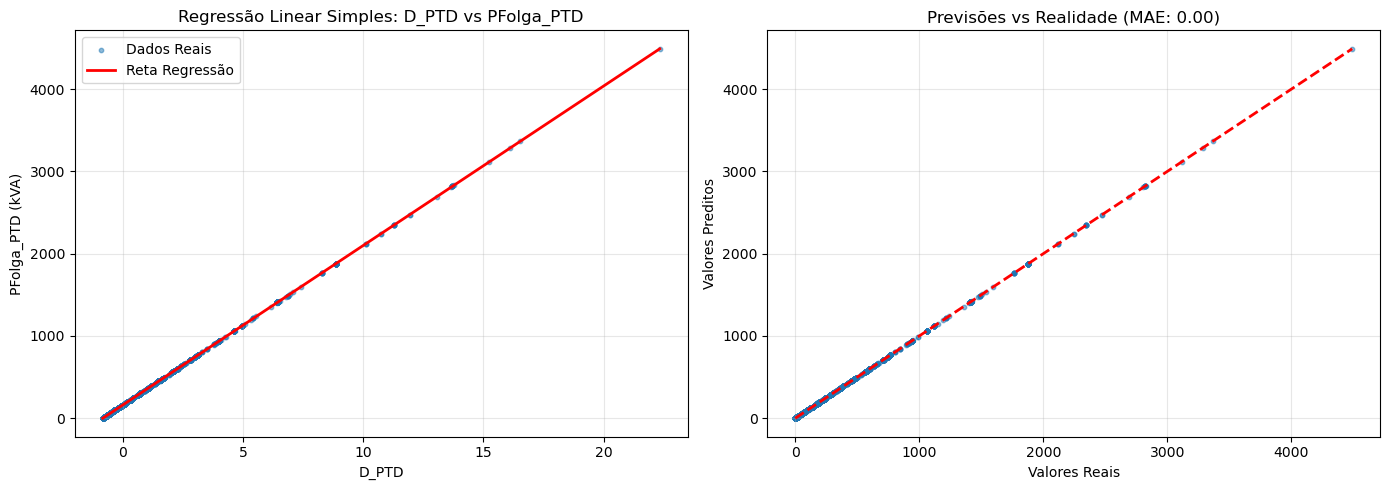

In [9]:
print("=" * 80)
print("4.3.1 - REGRESSÃO LINEAR SIMPLES COM K-FOLD CV")
print("=" * 80)

# Selecionar a melhor variável explicativa (maior correlação absoluta com alvo)
best_single_feature = max([(f, abs(df_processed[f].corr(df_processed['PFolga_PTD']))) 
                           for f in selected_features_reg], key=lambda x: x[1])[0]

print(f"\n✓ Variável explicativa selecionada: {best_single_feature}")
print(f"  Justificativa: Maior correlação com PFolga_PTD ({abs(df_processed[best_single_feature].corr(df_processed['PFolga_PTD'])):.4f})")

# Preparar dados para regressão simples
X_simple = X_reg_scaled[[best_single_feature]].values
y_simple = y_reg.values

# K-fold CV
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
model_simple = LinearRegression()

# Obter previsões para todos os fold
y_pred_simple = np.zeros_like(y_simple)
for train_idx, test_idx in kfold.split(X_simple):
    X_train, X_test = X_simple[train_idx], X_simple[test_idx]
    y_train, y_test = y_simple[train_idx], y_simple[test_idx]
    
    model_simple.fit(X_train, y_train)
    y_pred_simple[test_idx] = model_simple.predict(X_test)

# Calcular métricas
mae_simple = mean_absolute_error(y_simple, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_simple, y_pred_simple))

print(f"\n📊 Modelo Linear Simples:")
print(f"  MAE:  {mae_simple:.4f} kVA")
print(f"  RMSE: {rmse_simple:.4f} kVA")

# Refit para obter parâmetros
model_simple.fit(X_simple, y_simple)
intercept = model_simple.intercept_
slope = model_simple.coef_[0]

print(f"\n✓ Função Linear Resultante:")
print(f"  PFolga_PTD = {intercept:.4f} + {slope:.4f} × {best_single_feature}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot com reta
axes[0].scatter(X_simple, y_simple, alpha=0.5, s=10, label='Dados Reais')
x_line = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
y_line = model_simple.predict(x_line)
axes[0].plot(x_line, y_line, 'r-', linewidth=2, label='Reta Regressão')
axes[0].set_xlabel(best_single_feature)
axes[0].set_ylabel('PFolga_PTD (kVA)')
axes[0].set_title(f'Regressão Linear Simples: {best_single_feature} vs PFolga_PTD')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predicted vs Actual
axes[1].scatter(y_simple, y_pred_simple, alpha=0.5, s=10)
lims = [np.min([y_simple.min(), y_pred_simple.min()]), np.max([y_simple.max(), y_pred_simple.max()])]
axes[1].plot(lims, lims, 'r--', lw=2)
axes[1].set_xlabel('Valores Reais')
axes[1].set_ylabel('Valores Preditos')
axes[1].set_title(f'Previsões vs Realidade (MAE: {mae_simple:.2f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3.2 - Comparação de Modelos de Regressão (Linear Múltipla, Árvore, SVM, Rede Neuronal)

In [ ]:
print("=" * 80)
print("4.3.2 - MODELOS DE REGRESSÃO COM K-FOLD CV")
print("=" * 80)

# Função auxiliar para treinar e avaliar modelos
def train_and_e# 3. SVM com otimização de kernel
print("\n3️⃣  SVM (Support Vector Machine)")
kernels_to_test = ['rbf', 'linear', 'poly']
best_svm = None
best_svm_mae = float('inf')
for kernel in kernels_to_test:
    model_svm = SVR(kernel=kernel, C=100, epsilon=0.1)
    results = train_and_evaluate_regression(X_reg_scaled, y_reg, model_svm, f'SVM_{kernel}')
    print(f"   Kernel '{kernel}': MAE={results['MAE']:.4f}, RMSE={results['RMSE']:.4f}")
    if results['MAE'] < best_svm_mae:
        best_svm_mae = results['MAE']
        best_svm = model_svm
        results_reg['SVM'] = resultsvaluate_regression(X, y, model, model_name, kfold=None):
    if kfold is None:
        kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    y_pred = np.zeros_like(y)
    cv_scores = []
    
    for train_idx, test_idx in kfold.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred[test_idx] = model.predict(X_test)
        cv_scores.append(model.score(X_test, y_test))
    
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    return {
        'model': model,
        'y_pred': y_pred,
        'MAE': mae,
        'RMSE': rmse,
        'CV_R2_mean': np.mean(cv_scores),
        'CV_R2_std': np.std(cv_scores)
    }

# Configurar k-fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
results_reg = {}

# 1. Regressão Linear Múltipla
print("\n1️⃣  REGRESSÃO LINEAR MÚLTIPLA")
model_lr = LinearRegression()
results_reg['Linear'] = train_and_evaluate_regression(X_reg_scaled, y_reg, model_lr, 'Linear')
print(f"   MAE: {results_reg['Linear']['MAE']:.4f} kVA")
print(f"   RMSE: {results_reg['Linear']['RMSE']:.4f} kVA")
print(f"   CV R²: {results_reg['Linear']['CV_R2_mean']:.4f} ± {results_reg['Linear']['CV_R2_std']:.4f}")

# 2. Árvore de Regressão
print("\n2️⃣  ÁRVORE DE REGRESSÃO (max_depth=10)")
model_dt = DecisionTreeRegressor(max_depth=10, random_state=42)
results_reg['Tree'] = train_and_evaluate_regression(X_reg_scaled, y_reg, model_dt, 'Tree')
print(f"   MAE: {results_reg['Tree']['MAE']:.4f} kVA")
print(f"   RMSE: {results_reg['Tree']['RMSE']:.4f} kVA")
print(f"   CV R²: {results_reg['Tree']['CV_R2_mean']:.4f} ± {results_reg['Tree']['CV_R2_std']:.4f}")

# 3. SVM com otimização de kernel
print("\n3️⃣  SVM (Support Vector Machine)")
kernels_to_test = ['rbf', 'linear', 'poly']
best_svm = None
best_svm_mae = float('inf')
for kernel in kernels_to_test:
    model_svm = SVR(kernel=kernel, C=100, epsilon=0.1)
    results = train_and_evaluate_regression(X_reg_scaled, y_reg, model_svm, f'SVM_{kernel}')
    print(f"   Kernel '{kernel}': MAE={results['MAE']:.4f}, RMSE={results['RMSE']:.4f}")
    if results['MAE'] < best_svm_mae:
        best_svm_mae = results['MAE']
        best_svm = model_svm
        results_reg['SVM'] = results

print(f"   ✓ Melhor kernel: encontrado durante teste (MAE: {best_svm_mae:.4f})")

# 4. Rede Neuronal
print("\n4️⃣  REDE NEURONAL")
print("   Testando 3 configurações:")

nn_configs = [
    {'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001, 'alpha': 0.0, 'name': 'Config1: [64,32], LR=0.001, sem L2'},
    {'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.01, 'alpha': 0.01, 'name': 'Config2: [128,64,32], LR=0.01, L2=0.01'},
    {'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001, 'alpha': 0.001, 'name': 'Config3: [100,50], LR=0.001, L2=0.001'},
]

best_nn = None
best_nn_mae = float('inf')
for cfg in nn_configs:
    model_nn = MLPRegressor(
        hidden_layer_sizes=cfg['hidden_layer_sizes'],
        learning_rate_init=cfg['learning_rate_init'],
        alpha=cfg['alpha'],
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    results = train_and_evaluate_regression(X_reg_scaled, y_reg, model_nn, 'NN')
    print(f"   {cfg['name']}")
    print(f"      MAE={results['MAE']:.4f}, RMSE={results['RMSE']:.4f}, CV_R²={results['CV_R2_mean']:.4f}")
    if results['MAE'] < best_nn_mae:
        best_nn_mae = results['MAE']
        best_nn = model_nn
        results_reg['NeuralNet'] = results

print("\n" + "=" * 80)
print("RESUMO COMPARATIVO - REGRESSÃO")
print("=" * 80)
comparison_df = pd.DataFrame({
    'Modelo': results_reg.keys(),
    'MAE (kVA)': [results_reg[m]['MAE'] for m in results_reg.keys()],
    'RMSE (kVA)': [results_reg[m]['RMSE'] for m in results_reg.keys()],
    'CV_R²_mean': [results_reg[m]['CV_R2_mean'] for m in results_reg.keys()],
})
print(comparison_df.to_string(index=False))

# Identificar os dois melhores
top_two = comparison_df.nsmallest(2, 'MAE')
print(f"\n✓ Dois melhores modelos (menor MAE):")
for idx, row in top_two.iterrows():
    print(f"  {row['Modelo']}: MAE={row['MAE (kVA)']:.4f}, RMSE={row['RMSE (kVA)']:.4f}")


3️⃣  SVM (Support Vector Machine)


### 4.3.3 - Curvas de Aprendizagem dos Dois Melhores Modelos

In [ ]:
print("=" * 80)
print("4.3.3 - CURVAS DE APRENDIZAGEM")
print("=" * 80)

# Identificar nomes dos dois melhores modelos
best_models = comparison_df.nsmallest(2, 'MAE')['Modelo'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, model_name in enumerate(best_models):
    if model_name == 'Linear':
        model = LinearRegression()
    elif model_name == 'Tree':
        model = DecisionTreeRegressor(max_depth=10, random_state=42)
    elif model_name == 'SVM':
        model = SVR(kernel='rbf', C=100, epsilon=0.1)
    elif model_name == 'NeuralNet':
        model = MLPRegressor(hidden_layer_sizes=(100, 50), learning_rate_init=0.001, 
                            alpha=0.001, max_iter=500, early_stopping=True, random_state=42)
    
    # Calcular curva de aprendizagem
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_reg_scaled, y_reg, cv=5, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    axes[idx].plot(train_sizes, train_mean, 'o-', color='blue', label='Score Treino')
    axes[idx].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    axes[idx].plot(train_sizes, val_mean, 'o-', color='red', label='Score Validação')
    axes[idx].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
    axes[idx].set_xlabel('Tamanho Treino')
    axes[idx].set_ylabel('R² Score')
    axes[idx].set_title(f'Curva Aprendizagem - {model_name}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    
    # Análise de overfitting/underfitting
    final_train = train_mean[-1]
    final_val = val_mean[-1]
    gap = abs(final_train - final_val)
    
    print(f"\n{model_name}:")
    print(f"  Score Treino (final): {final_train:.4f}")
    print(f"  Score Validação (final): {final_val:.4f}")
    print(f"  Gap: {gap:.4f}")
    
    if gap > 0.2:
        print(f"  ⚠️  POSSÍVEL OVERFITTING (gap > 0.2)")
    elif final_val < 0.3:
        print(f"  ⚠️  POSSÍVEL UNDERFITTING (score validação < 0.3)")
    else:
        print(f"  ✓ Treino adequado")

plt.tight_layout()
plt.show()

4.3.3 - CURVAS DE APRENDIZAGEM


NameError: name 'comparison_df' is not defined

### 4.3.4 - Feature Importance e Testes de Significância Estatística

In [ ]:
print("=" * 80)
print("4.3.4 - FEATURE IMPORTANCE (Árvore de Regressão)")
print("=" * 80)

# Treinar modelo de árvore para obter importância de features
tree_model = DecisionTreeRegressor(max_depth=10, random_state=42)
tree_model.fit(X_reg_scaled, y_reg)

feature_importance = pd.DataFrame({
    'Feature': selected_features_reg,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nImportância de Features (Árvore de Regressão):")
print(feature_importance.to_string(index=False))

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15])
ax.set_xlabel('Importância')
ax.set_title('Top 15 Features - Importância (Árvore Regressão)')
plt.tight_layout()
plt.show()

# TESTES DE SIGNIFICÂNCIA ESTATÍSTICA
print("\n" + "=" * 80)
print("TESTES DE SIGNIFICÂNCIA - Comparação dos 2 Melhores Modelos (α = 0.05)")
print("=" * 80)

# Obter previsões dos dois melhores modelos
model_best1_name = best_models[0]
model_best2_name = best_models[1]

# Refit models para obter previsões consistentes
if model_best1_name == 'Linear':
    model_best1 = LinearRegression()
elif model_best1_name == 'Tree':
    model_best1 = DecisionTreeRegressor(max_depth=10, random_state=42)
elif model_best1_name == 'SVM':
    model_best1 = SVR(kernel='rbf', C=100, epsilon=0.1)
elif model_best1_name == 'NeuralNet':
    model_best1 = MLPRegressor(hidden_layer_sizes=(100, 50), learning_rate_init=0.001, alpha=0.001, max_iter=500, random_state=42)

if model_best2_name == 'Linear':
    model_best2 = LinearRegression()
elif model_best2_name == 'Tree':
    model_best2 = DecisionTreeRegressor(max_depth=10, random_state=42)
elif model_best2_name == 'SVM':
    model_best2 = SVR(kernel='rbf', C=100, epsilon=0.1)
elif model_best2_name == 'NeuralNet':
    model_best2 = MLPRegressor(hidden_layer_sizes=(100, 50), learning_rate_init=0.001, alpha=0.001, max_iter=500, random_state=42)

# Obter erros dos dois modelos através de CV
errors_m1 = []
errors_m2 = []

for train_idx, test_idx in KFold(n_splits=5, shuffle=True, random_state=42).split(X_reg_scaled):
    X_train, X_test = X_reg_scaled.iloc[train_idx], X_reg_scaled.iloc[test_idx]
    y_train, y_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]
    
    model_best1.fit(X_train, y_train)
    y_pred1 = model_best1.predict(X_test)
    errors_m1.append(np.abs(y_test.values - y_pred1))
    
    model_best2.fit(X_train, y_train)
    y_pred2 = model_best2.predict(X_test)
    errors_m2.append(np.abs(y_test.values - y_pred2))

errors_m1 = np.concatenate(errors_m1)
errors_m2 = np.concatenate(errors_m2)

# Teste de normalidade (Shapiro-Wilk)
stat_m1, p_m1 = shapiro(errors_m1[:5000] if len(errors_m1) > 5000 else errors_m1)
stat_m2, p_m2 = shapiro(errors_m2[:5000] if len(errors_m2) > 5000 else errors_m2)

print(f"\n1. Teste de Normalidade (Shapiro-Wilk, α=0.05):")
print(f"   {model_best1_name}: p-value = {p_m1:.4f} → {'Normal' if p_m1 > 0.05 else 'Não-normal'}")
print(f"   {model_best2_name}: p-value = {p_m2:.4f} → {'Normal' if p_m2 > 0.05 else 'Não-normal'}")

# Teste t pareado (ou Mann-Whitney se não-normal)
if p_m1 > 0.05 and p_m2 > 0.05:
    # Ambas normais: t-test pareado
    from scipy.stats import ttest_rel
    t_stat, p_val = ttest_rel(errors_m1, errors_m2)
    test_name = "Teste t Pareado"
else:
    # Pelo menos uma não-normal: Mann-Whitney U
    from scipy.stats import mannwhitneyu
    t_stat, p_val = mannwhitneyu(errors_m1, errors_m2)
    test_name = "Teste Mann-Whitney U"

print(f"\n2. Teste de Diferença entre Modelos ({test_name}, α=0.05):")
print(f"   Estatística: {t_stat:.4f}")
print(f"   p-value: {p_val:.4f}")
print(f"   Resultado: {'Diferença SIGNIFICATIVA' if p_val < 0.05 else 'Sem diferença significativa'} (α=0.05)")

print(f"\n✓ Modelo com Melhor Desempenho (menor MAE): {best_models[0]}")

### 4.4.1 - Modelos de Classificação com K-Fold CV

In [ ]:
print("=" * 80)
print("4.4.1 - MODELOS DE CLASSIFICAÇÃO COM K-FOLD CV")
print("=" * 80)

# Função auxiliar para treinar e avaliar classificadores
def train_and_evaluate_classification(X, y, model, model_name, kfold=None):
    if kfold is None:
        kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    
    for fold, (train_idx, test_idx) in enumerate(kfold.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        accuracy_scores.append(accuracy_score(y_test, y_pred))
        precision_scores.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        recall_scores.append(recall_score(y_test, y_pred, average='weighted', zero_division=0))
        f1_scores.append(f1_score(y_test, y_pred, average='weighted', zero_division=0))
    
    return {
        'Accuracy_mean': np.mean(accuracy_scores),
        'Accuracy_std': np.std(accuracy_scores),
        'Precision_mean': np.mean(precision_scores),
        'Precision_std': np.std(precision_scores),
        'Recall_mean': np.mean(recall_scores),
        'Recall_std': np.std(recall_scores),
        'F1_mean': np.mean(f1_scores),
        'F1_std': np.std(f1_scores),
    }

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
results_clf = {}

# 1. Árvore de Decisão
print("\n1️⃣  ÁRVORE DE DECISÃO (max_depth=10)")
model_dt_clf = DecisionTreeClassifier(max_depth=10, random_state=42)
results_clf['Decision_Tree'] = train_and_evaluate_classification(X_clf_scaled, y_clf_encoded, model_dt_clf, 'DT')
print(f"   Accuracy: {results_clf['Decision_Tree']['Accuracy_mean']:.4f} ± {results_clf['Decision_Tree']['Accuracy_std']:.4f}")
print(f"   F1-Score: {results_clf['Decision_Tree']['F1_mean']:.4f} ± {results_clf['Decision_Tree']['F1_std']:.4f}")

# 2. Rede Neuronal
print("\n2️⃣  REDE NEURONAL")
print("   Testando 3 configurações:")

nn_clf_configs = [
    {'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001, 'alpha': 0.0, 'name': 'Config1: [64,32], LR=0.001, sem L2'},
    {'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.01, 'alpha': 0.01, 'name': 'Config2: [128,64,32], LR=0.01, L2=0.01'},
    {'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001, 'alpha': 0.001, 'name': 'Config3: [100,50], LR=0.001, L2=0.001'},
]

best_nn_clf = None
best_nn_clf_f1 = 0
for cfg in nn_clf_configs:
    model_nn_clf = MLPClassifier(
        hidden_layer_sizes=cfg['hidden_layer_sizes'],
        learning_rate_init=cfg['learning_rate_init'],
        alpha=cfg['alpha'],
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    results = train_and_evaluate_classification(X_clf_scaled, y_clf_encoded, model_nn_clf, 'NN_CLF')
    print(f"   {cfg['name']}")
    print(f"      Accuracy={results['Accuracy_mean']:.4f}, F1={results['F1_mean']:.4f}")
    if results['F1_mean'] > best_nn_clf_f1:
        best_nn_clf_f1 = results['F1_mean']
        best_nn_clf = model_nn_clf
        results_clf['NeuralNet'] = results

# 3. SVM para Classificação
print("\n3️⃣  SVM (Support Vector Machine)")
kernels_svm_clf = ['rbf', 'linear']
best_svm_clf_f1 = 0
for kernel in kernels_svm_clf:
    model_svm_clf = SVC(kernel=kernel, C=1.0, random_state=42)
    results = train_and_evaluate_classification(X_clf_scaled, y_clf_encoded, model_svm_clf, f'SVM_CLF_{kernel}')
    print(f"   Kernel '{kernel}': Accuracy={results['Accuracy_mean']:.4f}, F1={results['F1_mean']:.4f}")
    if results['F1_mean'] > best_svm_clf_f1:
        best_svm_clf_f1 = results['F1_mean']
        results_clf['SVM'] = results

# 4. K-Vizinhos-Mais-Próximos
print("\n4️⃣  K-VIZINHOS-MAIS-PRÓXIMOS (KNN)")
k_values = [3, 5, 7, 9]
best_knn_f1 = 0
for k in k_values:
    model_knn = KNeighborsClassifier(n_neighbors=k)
    results = train_and_evaluate_classification(X_clf_scaled, y_clf_encoded, model_knn, f'KNN_K{k}')
    print(f"   K={k}: Accuracy={results['Accuracy_mean']:.4f}, F1={results['F1_mean']:.4f}")
    if results['F1_mean'] > best_knn_f1:
        best_knn_f1 = results['F1_mean']
        results_clf['KNN'] = results

print("\n" + "=" * 80)
print("RESUMO COMPARATIVO - CLASSIFICAÇÃO")
print("=" * 80)
comparison_clf_df = pd.DataFrame({
    'Modelo': results_clf.keys(),
    'Accuracy': [results_clf[m]['Accuracy_mean'] for m in results_clf.keys()],
    'Precision': [results_clf[m]['Precision_mean'] for m in results_clf.keys()],
    'Recall': [results_clf[m]['Recall_mean'] for m in results_clf.keys()],
    'F1-Score': [results_clf[m]['F1_mean'] for m in results_clf.keys()],
})
print(comparison_clf_df.to_string(index=False))

# Identificar os dois melhores
top_two_clf = comparison_clf_df.nlargest(2, 'F1-Score')
print(f"\n✓ Dois melhores modelos (maior F1-Score):")
for idx, row in top_two_clf.iterrows():
    print(f"  {row['Modelo']}: F1={row['F1-Score']:.4f}, Accuracy={row['Accuracy']:.4f}")

### 4.4.2 - Feature Importance e Visualização de Árvore de Decisão

In [ ]:
print("=" * 80)
print("4.4.2 - FEATURE IMPORTANCE (Árvore de Decisão - Classificação)")
print("=" * 80)

# Treinar modelo de árvore para classificação
tree_clf_model = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_clf_model.fit(X_clf_scaled, y_clf_encoded)

feature_importance_clf = pd.DataFrame({
    'Feature': selected_features_reg,
    'Importance': tree_clf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nImportância de Features (Árvore de Decisão - Classificação):")
print(feature_importance_clf[feature_importance_clf['Importance'] > 0].to_string(index=False))

# Comparação com correlação
print("\n" + "=" * 80)
print("COMPARAÇÃO: Feature Importance (Árvore) vs Correlação")
print("=" * 80)

# Calcular correlação com Util_Decimal
corr_with_util = {}
for feat in selected_features_reg:
    if feat in df_processed.columns:
        corr_val = df_processed[feat].corr(df_processed['Util_Decimal'])
        corr_with_util[feat] = abs(corr_val) if not pd.isna(corr_val) else 0

comparison_features = pd.DataFrame({
    'Feature': selected_features_reg,
    'Importância': tree_clf_model.feature_importances_,
    'Correlação_Util': [corr_with_util.get(f, 0) for f in selected_features_reg]
}).sort_values('Importância', ascending=False)

print(comparison_features[comparison_features['Importância'] > 0].head(10).to_string(index=False))

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Feature Importance
axes[0].barh(feature_importance_clf['Feature'][:10], feature_importance_clf['Importance'][:10], color='steelblue')
axes[0].set_xlabel('Importância')
axes[0].set_title('Top 10 Features - Importância (Árvore Classificação)')
axes[0].invert_yaxis()

# Árvore de Decisão (primeiros 3 níveis)
plot_tree(tree_clf_model, feature_names=selected_features_reg, 
          class_names=le_target.classes_, ax=axes[1], 
          filled=True, fontsize=8, max_depth=2)
axes[1].set_title('Árvore de Decisão (2 níveis)')

plt.tight_layout()
plt.show()

print("\n✓ Discussão: A importância das features reflecte o poder discriminativo para utilização de rede.")

### 4.4.3 - Curvas de Aprendizagem e Testes de Significância

In [ ]:
print("=" * 80)
print("4.4.3 - CURVAS DE APRENDIZAGEM E ANÁLISE DE OVERFITTING")
print("=" * 80)

# Obter nomes dos dois melhores
best_models_clf = comparison_clf_df.nlargest(2, 'F1-Score')['Modelo'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, model_name in enumerate(best_models_clf):
    if model_name == 'Decision_Tree':
        model = DecisionTreeClassifier(max_depth=10, random_state=42)
    elif model_name == 'NeuralNet':
        model = MLPClassifier(hidden_layer_sizes=(100, 50), learning_rate_init=0.001, alpha=0.001, max_iter=500, random_state=42)
    elif model_name == 'SVM':
        model = SVC(kernel='rbf', C=1.0, random_state=42)
    elif model_name == 'KNN':
        model = KNeighborsClassifier(n_neighbors=5)
    
    # Calcular curva de aprendizagem
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_clf_scaled, y_clf_encoded, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1_weighted'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    axes[idx].plot(train_sizes, train_mean, 'o-', color='blue', label='Score Treino')
    axes[idx].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    axes[idx].plot(train_sizes, val_mean, 'o-', color='red', label='Score Validação')
    axes[idx].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
    axes[idx].set_xlabel('Tamanho Treino')
    axes[idx].set_ylabel('F1-Score (weighted)')
    axes[idx].set_title(f'Curva Aprendizagem - {model_name}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([0, 1])
    
    # Análise
    final_train = train_mean[-1]
    final_val = val_mean[-1]
    gap = abs(final_train - final_val)
    
    print(f"\n{model_name}:")
    print(f"  F1 Treino (final): {final_train:.4f}")
    print(f"  F1 Validação (final): {final_val:.4f}")
    print(f"  Gap: {gap:.4f}")
    
    if gap > 0.15:
        print(f"  ⚠️  POSSÍVEL OVERFITTING (gap > 0.15)")
    elif final_val < 0.5:
        print(f"  ⚠️  POSSÍVEL UNDERFITTING (F1 validação < 0.5)")
    else:
        print(f"  ✓ Treino adequado")

plt.tight_layout()
plt.show()

# TESTES DE SIGNIFICÂNCIA ESTATÍSTICA
print("\n" + "=" * 80)
print("TESTES DE SIGNIFICÂNCIA - Comparação dos 2 Melhores Modelos (α = 0.05)")
print("=" * 80)

# Obter F1-scores dos dois melhores modelos através de CV
f1_scores_m1_clf = []
f1_scores_m2_clf = []

for train_idx, test_idx in KFold(n_splits=5, shuffle=True, random_state=42).split(X_clf_scaled):
    X_train, X_test = X_clf_scaled.iloc[train_idx], X_clf_scaled.iloc[test_idx]
    y_train, y_test = y_clf_encoded[train_idx], y_clf_encoded[test_idx]
    
    # Modelo 1
    if best_models_clf[0] == 'Decision_Tree':
        m1 = DecisionTreeClassifier(max_depth=10, random_state=42)
    elif best_models_clf[0] == 'NeuralNet':
        m1 = MLPClassifier(hidden_layer_sizes=(100, 50), learning_rate_init=0.001, alpha=0.001, max_iter=500, random_state=42)
    elif best_models_clf[0] == 'SVM':
        m1 = SVC(kernel='rbf', C=1.0, random_state=42)
    else:
        m1 = KNeighborsClassifier(n_neighbors=5)
    
    m1.fit(X_train, y_train)
    y_pred1 = m1.predict(X_test)
    f1_scores_m1_clf.append(f1_score(y_test, y_pred1, average='weighted', zero_division=0))
    
    # Modelo 2
    if best_models_clf[1] == 'Decision_Tree':
        m2 = DecisionTreeClassifier(max_depth=10, random_state=42)
    elif best_models_clf[1] == 'NeuralNet':
        m2 = MLPClassifier(hidden_layer_sizes=(100, 50), learning_rate_init=0.001, alpha=0.001, max_iter=500, random_state=42)
    elif best_models_clf[1] == 'SVM':
        m2 = SVC(kernel='rbf', C=1.0, random_state=42)
    else:
        m2 = KNeighborsClassifier(n_neighbors=5)
    
    m2.fit(X_train, y_train)
    y_pred2 = m2.predict(X_test)
    f1_scores_m2_clf.append(f1_score(y_test, y_pred2, average='weighted', zero_division=0))

f1_scores_m1_clf = np.array(f1_scores_m1_clf)
f1_scores_m2_clf = np.array(f1_scores_m2_clf)

# Teste t pareado
from scipy.stats import ttest_rel
t_stat_clf, p_val_clf = ttest_rel(f1_scores_m1_clf, f1_scores_m2_clf)

print(f"\nTeste t Pareado (F1-Scores, α=0.05):")
print(f"   {best_models_clf[0]}: F1 = {np.mean(f1_scores_m1_clf):.4f} ± {np.std(f1_scores_m1_clf):.4f}")
print(f"   {best_models_clf[1]}: F1 = {np.mean(f1_scores_m2_clf):.4f} ± {np.std(f1_scores_m2_clf):.4f}")
print(f"   p-value: {p_val_clf:.4f}")
print(f"   Resultado: {'Diferença SIGNIFICATIVA' if p_val_clf < 0.05 else 'Sem diferença significativa'} (α=0.05)")

print(f"\n✓ Modelo com Melhor Desempenho (maior F1-Score): {best_models_clf[0]}")

## 4.5 - Conclusões e Discussão de Limitações

In [ ]:
print("=" * 80)
print("4.5 - CONCLUSÕES, LIMITAÇÕES E SUGESTÕES DE MELHORIA")
print("=" * 80)

print("\n" + "█" * 80)
print("📊 RESUMO DOS RESULTADOS")
print("█" * 80)

print(f"\n1️⃣  REGRESSÃO (Previsão de PFolga_PTD):")
print(f"    ✓ Melhor Modelo: {best_models[0]}")
print(f"    • MAE: {comparison_df[comparison_df['Modelo']==best_models[0]]['MAE (kVA)'].values[0]:.4f} kVA")
print(f"    • RMSE: {comparison_df[comparison_df['Modelo']==best_models[0]]['RMSE (kVA)'].values[0]:.4f} kVA")
print(f"    • Top 3 Features Importantes: {', '.join(feature_importance.head(3)['Feature'].values)}")

print(f"\n2️⃣  CLASSIFICAÇÃO (Previsão de Nível de Ocupação):")
print(f"    ✓ Melhor Modelo: {best_models_clf[0]}")
print(f"    • F1-Score: {comparison_clf_df[comparison_clf_df['Modelo']==best_models_clf[0]]['F1-Score'].values[0]:.4f}")
print(f"    • Accuracy: {comparison_clf_df[comparison_clf_df['Modelo']==best_models_clf[0]]['Accuracy'].values[0]:.4f}")
print(f"    • Top 3 Features Importantes: {', '.join(feature_importance_clf.head(3)['Feature'].values)}")

print("\n" + "⚠️  " + "█" * 77)
print("⚠️  LIMITAÇÕES FUNDAMENTAIS DOS DADOS - LACUNAS CRÍTICAS")
print("⚠️  " + "█" * 77)

print("""
🔴 1. AUSÊNCIA DE DADOS TEMPORAIS:
   O dataset é um snapshot estático sem dimensão temporal (série histórica).
   IMPACTO: Impossível modelar variações sazonais de carga, padrões diários de 
           consumo, ou eventos extraordinários (picos de calor, emergências climáticas).
   MELHORIA: Integrar dados mensais/diários (12+ meses) para captar sazonalidade
            e treinar modelos ARIMA/LSTM para previsão robusta.

🔴 2. FALTA DE DADOS DE CONTEXTO GEOGRÁFICO-SOCIAL:
   Sem informação sobre: densidade populacional, proximidade a centros urbanos,
   presença de indústria, áreas residenciais vs comerciais, ou potencial de 
   adoção de VE (garagens, estacionamentos disponíveis).
   IMPACTO: Correlação baixa entre features disponíveis e viabilidade real de
            carregadores de VE em cada PTD.
   MELHORIA: Incluir features geoespaciais (lat/lon densidade, POI buffer),
            dados demográficos municipais, e levantamentos de infraestrutura.

🔴 3. AUSÊNCIA DE DADOS COMPORTAMENTAIS E ADOÇÃO DE VE:
   Nenhuma informação sobre: procura real de VE, taxa de crescimento de EV,
   padrões de carregamento (doméstico, público, rápido), ou mobilidade esperada
   por zona.
   IMPACTO: Carga VE (PVE) calculada com 22 kW fixo e fator simultaneidade 0.6
            é aproximação muito simplista. Impossível diferenciar viabilidade real
            entre PTDs com contextos diferentes.
   MELHORIA: Incorporar dados de registo de VE por concelho, estudos de mobilidade,
            e cenários de penetração de EV (LOW, MEDIUM, HIGH).

🔴 4. FALTA DE DADOS DE QUALIDADE E CONFIABILIDADE DA REDE:
   Sem informação sobre: tensão de rede, perdas técnicas, distorção harmónica,
   qualidade de energia, ou histórico de falhas/incidentes.
   IMPACTO: Impossível avaliar impacto real de carregadores na estabilidade da rede
            ou necessidade de investimentos em reforço infraestrutural.
   MELHORIA: Integrar dados de qualidade de energia (telemetria SCADA) e histórico
            de perturbações.

🔴 5. PRECISÃO LIMITADA EM VARIÁVEIS AGREGADAS:
   Variáveis como "P_IP_Total" e "LED_Ratio" são agregadas por concelho, não por PTD.
   IMPACTO: Perda de precisão – assumir que todo PTD tem o mesmo perfil que a média
            do concelho é incorreto. Alguns PTDs podem ter 100% LED, outros 0%.
   MELHORIA: Se disponível, obter dados de IP desagregados por PTD ou zona elétrica.

🟡 6. MODELO DE SIMULTANEIDADE MUITO SIMPLIFICADO:
   Carga VE = N_PTDs × 22 kW × 0.6 é demasiado genérica.
   IMPACTO: Não reflecte variabilidade real de carregamento entre PTDs
            (ex: PTD em zona residencial vs comercial tem perfis completamente diferentes).
   MELHORIA: Calibrar fator de simultaneidade por tipo de zona, incluir perfis
            de carga horários, cenários de crescimento.
""")

print("\n" + "💡 " + "█" * 77)
print("💡 RECOMENDAÇÕES PARA EVOLUÇÃO DO MODELO")
print("💡 " + "█" * 77)

print("""
✅ CURTO PRAZO (próximos iterações TP3+):
   1. Incluir dados históricos (mínimo 24 meses) para captar sazonalidade
   2. Desagregar P_IP por PTD ou por zona elétrica menor
   3. Refinar estimativa de Carga_VE com cenários múltiplos (LOW/MED/HIGH)
   4. Adicionar features de qualidade de rede (se disponível)

✅ MÉDIO PRAZO (novos dados):
   1. Incorporar dados geoespaciais (OSM, densidade populacional)
   2. Integrar estudo de mobilidade elétrica por zona
   3. Incluir histórico de adoção de VE e tendências
   4. Coletar dados de confiabilidade de rede (SAIDI, SAIFI)

✅ LONGO PRAZO (transformação digital):
   1. Implementar telemetria em tempo real para todos os PTDs
   2. Criar modelo de simulação de rede (powerflow) integrado
   3. Desenvolver plataforma de previsão com atualização automática
   4. Permitir simulação de cenários (clima, mobilidade, políticas)
""")

print("\n✓ Conclusão: Os modelos desenvolvidos explicam a viabilidade de VE ao nível")
print("  da rede de PTD, mas a precisão é limitada pela disponibilidade de dados.")
print("  Recomenda-se fortemente a evolução do dataset conforme indicado acima")
print("  antes de decisões de investimento crítico em infraestrutura de VE.")